In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"


 ACP						'MS Office'
'Colab Notebooks'				'My POC Card'
'CSS Essential Certificate.pdf'			 old
 Dataset					 Pass
 deepface-master				'Semester 5'
'Discovering Entrepreneurship Certificate.pdf'	'Semester 7th'
 facedectection.v2i.coco2			'Semester 9th'
 facemodel					 testing
'HTML Essential Certificate.pdf'		 vgg16_custom_model_v4.h5


Found 12 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step

Classification Report:
              precision    recall  f1-score   support

      Class1       0.33      0.20      0.25         5
      Class2       0.56      0.71      0.62         7

    accuracy                           0.50        12
   macro avg       0.44      0.46      0.44        12
weighted avg       0.46      0.50      0.47        12



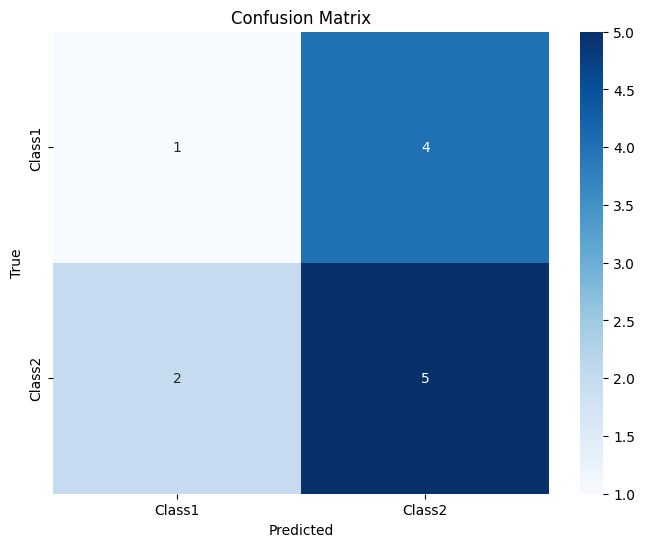

In [ ]:
# STEP 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# STEP 2: Set paths and parameters
model_path = "/content/drive/MyDrive/vgg16_custom_model_v4.h5"
dataset_path = "/content/drive/MyDrive/Dataset"
img_size = 224
batch_size = 32

# STEP 3: Load the model
model = load_model(model_path)

# STEP 4: Prepare validation data generator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,  # Important for matching predictions with filenames
    subset='validation'
)

# STEP 5: Predict
predictions = model.predict(val_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

# STEP 6: Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# STEP 7: Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


📁 Please upload the FIRST image:


Saving img6.jpg to img6.jpg
📁 Please upload the SECOND image:


Saving img7.jpg to img7.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step

Cosine Similarity: 0.5415


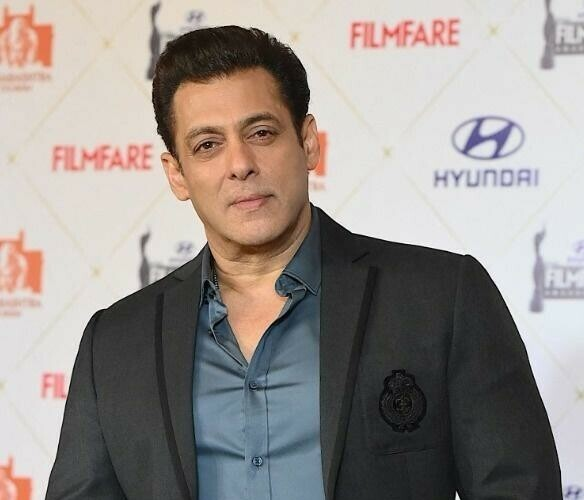

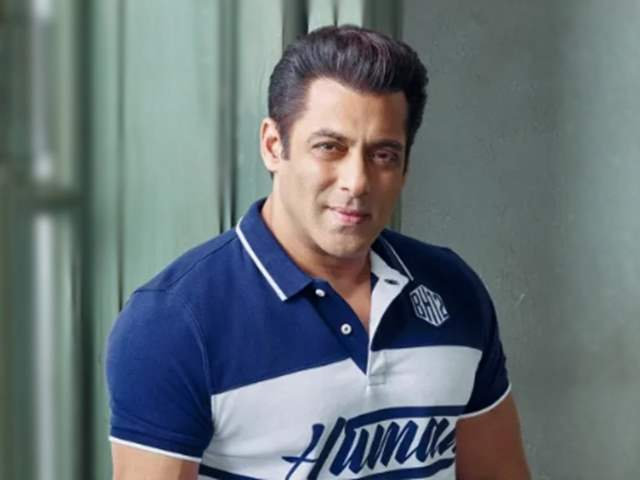

✅ Same person


In [ ]:
# STEP 1: Import libraries
import numpy as np
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import files
from IPython.display import Image, display

# STEP 2: Load the model
model_path = "/content/drive/MyDrive/vgg16_custom_model_v4.h5"
model = load_model(model_path)

# STEP 3: Define preprocessing and embedding functions
def preprocess_img(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

def get_embedding(model, img_path):
    img = preprocess_img(img_path)
    feature_extractor = Model(inputs=model.input, outputs=model.layers[-2].output)
    embedding = feature_extractor.predict(img)
    return embedding

def compare_faces(img1_path, img2_path, threshold=0.5):
    emb1 = get_embedding(model, img1_path)
    emb2 = get_embedding(model, img2_path)

    similarity = cosine_similarity(emb1, emb2)[0][0]
    print(f"\nCosine Similarity: {similarity:.4f}")

    display(Image(img1_path))
    display(Image(img2_path))

    if similarity > threshold:
        print("✅ Same person")
    else:
        print("❌ Different people")

# STEP 4: Upload two images
print("📁 Please upload the FIRST image:")
uploaded1 = files.upload()

print("📁 Please upload the SECOND image:")
uploaded2 = files.upload()

# STEP 5: Compare
img1_path = list(uploaded1.keys())[0]
img2_path = list(uploaded2.keys())[0]
compare_faces(img1_path, img2_path)
